# Lab Experiment: Comparison of Logistic Regression and K-Nearest Neighbors (KNN) Classifiers




## Task 1: Download and Load the Dataset ##

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

sns.set_style("whitegrid")


In [2]:
# Column names as per wdbc.names
feature_base = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

columns = ['id', 'diagnosis']
for stat in ['mean', 'se', 'worst']:
    columns += [f'{f}_{stat}' for f in feature_base]

df = pd.read_csv('wdbc.data', header=None, names=columns)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Task 2: Exploratory Data Analysis and Preprocessing

In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave_points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


diagnosis
B    357
M    212
Name: count, dtype: int64


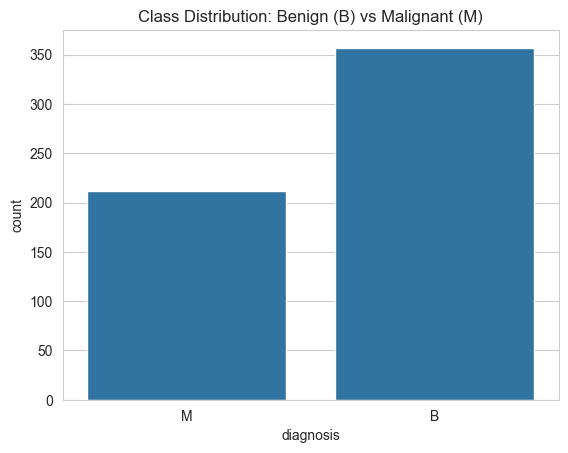

In [5]:
# Class distribution
print(df['diagnosis'].value_counts())
sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution: Benign (B) vs Malignant (M)')
plt.show()

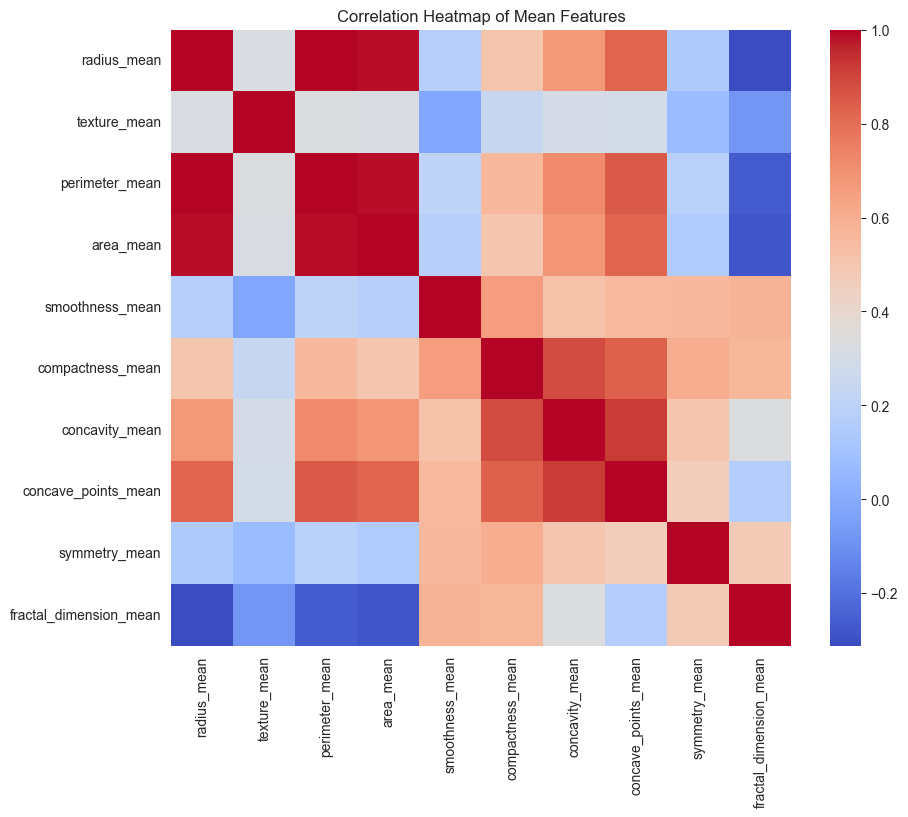

In [6]:
# Correlation heatmap of a subset of mean features
mean_cols = [c for c in df.columns if c.endswith('_mean')]
plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap of Mean Features')
plt.show()

## Task 3: Check for Missing Values and Prepare the Dataset

In [7]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum().sum())

# Drop the ID column (not a predictive feature)
df = df.drop(columns=['id'])

# Encode target: Malignant = 1, Benign = 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Missing values per column:
 0
Feature matrix shape: (569, 30)
Target distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


## Task 4: Split the Dataset into Training and Testing Sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (important for both Logistic Regression convergence and KNN distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Testing set size:", X_test_scaled.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


## Task 5: Train a Logistic Regression Classifier

In [9]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## Task 6: Train a K-Nearest Neighbors (KNN) Classifier

First we find a good value of k by checking accuracy across a range of k values, then train the final KNN model.

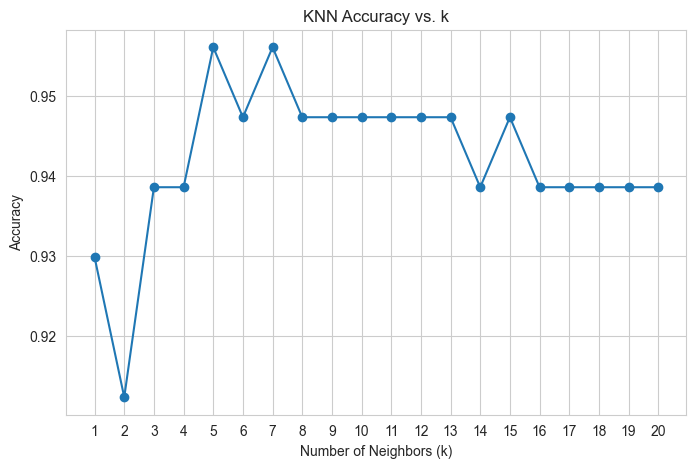

Best k: 5 with accuracy: 0.9561


In [10]:
# Find the best k using the test set accuracy (for demonstration purposes)
k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs. k')
plt.xticks(list(k_range))
plt.show()

best_k = k_range[np.argmax(accuracies)]
print(f"Best k: {best_k} with accuracy: {max(accuracies):.4f}")

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print("KNN trained successfully with k =", best_k)

KNN trained successfully with k = 5


## Task 7: Evaluate Both Classifiers

We compute Accuracy, Precision, Recall, F1 Score, and Confusion Matrix for each classifier.

In [12]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'Confusion Matrix': cm}

log_results = evaluate_model("Logistic Regression", y_test, y_pred_log)

--- Logistic Regression ---
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1 Score : 0.9512
Confusion Matrix:
 [[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [13]:
knn_results = evaluate_model("K-Nearest Neighbors", y_test, y_pred_knn)

--- K-Nearest Neighbors ---
Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383
Confusion Matrix:
 [[71  1]
 [ 4 38]]

Classification Report:
               precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



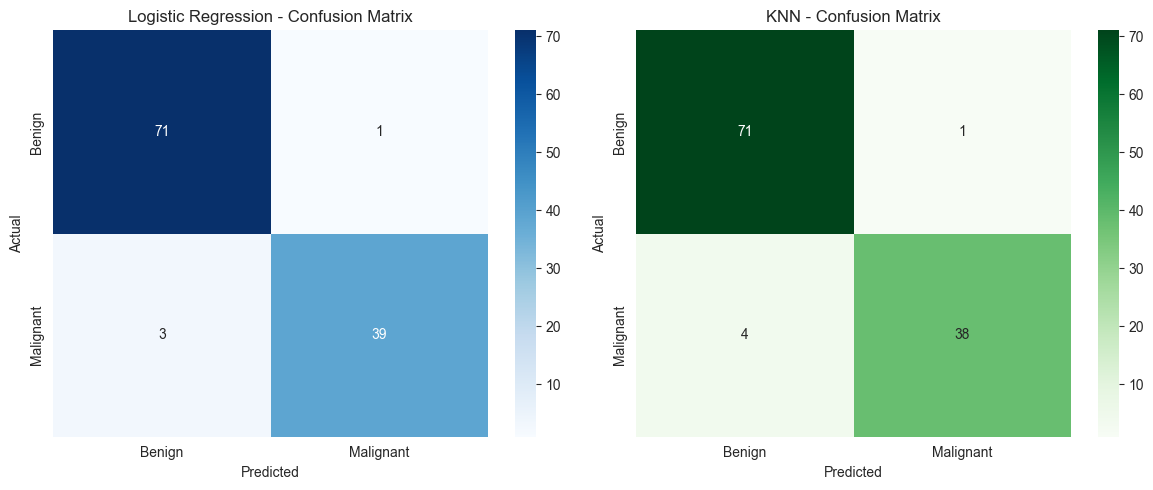

In [14]:
# Visualize confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(log_results['Confusion Matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(knn_results['Confusion Matrix'], annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], ax=axes[1])
axes[1].set_title('KNN - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

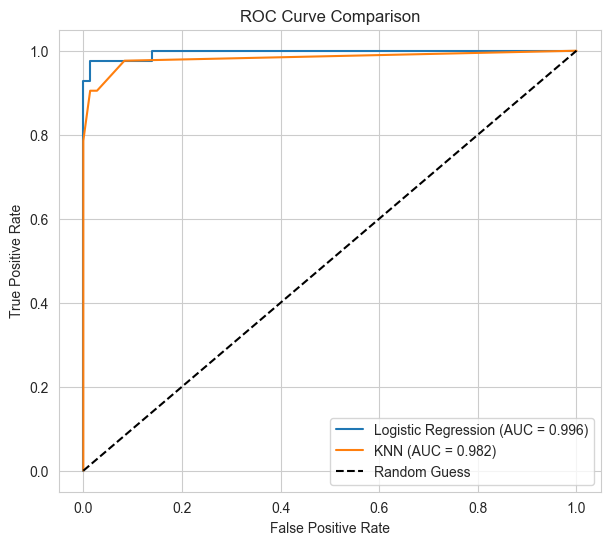

In [15]:
# ROC Curves
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Task 8: Compare the Performance of the Two Classifiers

In [16]:
comparison_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': log_results['Accuracy'], 'Precision': log_results['Precision'],
     'Recall': log_results['Recall'], 'F1 Score': log_results['F1 Score'], 'AUC': auc_log},
    {'Model': 'KNN', 'Accuracy': knn_results['Accuracy'], 'Precision': knn_results['Precision'],
     'Recall': knn_results['Recall'], 'F1 Score': knn_results['F1 Score'], 'AUC': auc_knn},
])

comparison_df.set_index('Model', inplace=True)
comparison_df.round(4)

,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
KNN,0.9561,0.9744,0.9048,0.9383,0.9823


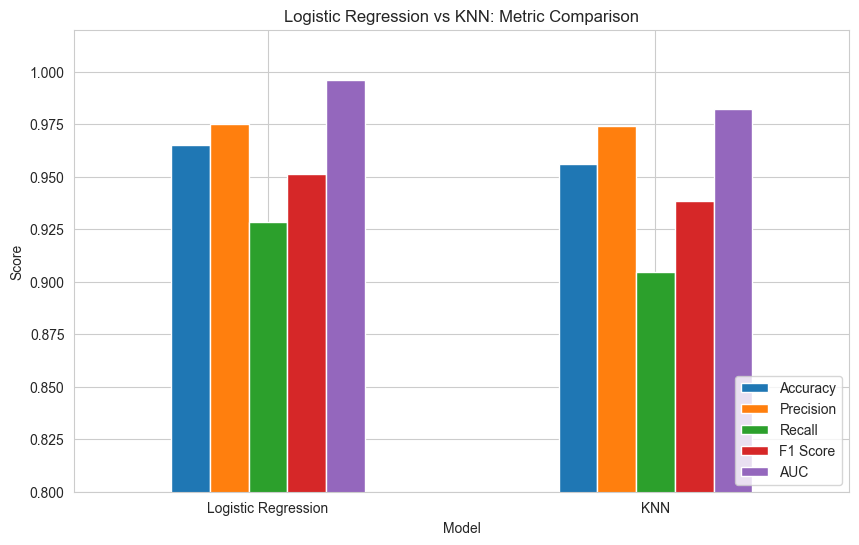

In [17]:
comparison_df.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Logistic Regression vs KNN: Metric Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.02)
plt.legend(loc='lower right')
plt.show()

**Conclusion:** Logistic Regression outperformed KNN, with higher **Recall** and **AUC**. Since Recall is critical for detecting malignant tumors, Logistic Regression is the better classifier for this dataset.